# EE 656 Final Project — Predicting Missed Medical Appointments

## **Name:** Sadia Yesmin Shampa

---
# Part 1 – Load and Understand the Two Datasets

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
patients = pd.read_csv("clinic_patients.csv")
appointments = pd.read_csv("clinic_appointments.csv")

print(patients.head())
print(appointments.head())

  PatientID  Age InsuranceType  DistanceMiles Diabetes Hypertension  \
0     P0001   75      Medicare            1.7       No           No   
1     P0002   88      Medicare            4.2       No           No   
2     P0003   20      Medicaid           11.8       No           No   
3     P0004   87       Private           11.8       No          Yes   
4     P0005   60       Private            1.7       No           No   

  PreferredContact  
0             Text  
1             Text  
2             Text  
3            Phone  
4            Phone  
  AppointmentID PatientID AppointmentDate AppointmentType        TimeSlot  \
0        A00001     P0065      2025-09-30    Primary Care  Late Afternoon   
1        A00002     P0680      2025-09-03       Follow-Up       Afternoon   
2        A00003     P0514      2025-03-24       Follow-Up  Late Afternoon   
3        A00004     P0746      2025-10-23   Endocrinology         Morning   
4        A00005     P0168      2025-06-09       Follow-Up     

**•	What does one row in patients represent?**

One person registered at the clinic, with details that stay the same across visits.

**•	What does one row in appointments represent?**

One scheduled visit. The same patient can appear on many rows.

In [3]:
print("Patients shape:", patients.shape)
print("Appointments shape:", appointments.shape)

print("Patient columns:")
print(patients.columns.tolist())

print("Appointment columns:")
print(appointments.columns.tolist())

print("Missing values in patients:")
print(patients.isna().sum())

print("Missing values in appointments:")
print(appointments.isna().sum())

Patients shape: (800, 7)
Appointments shape: (3200, 11)
Patient columns:
['PatientID', 'Age', 'InsuranceType', 'DistanceMiles', 'Diabetes', 'Hypertension', 'PreferredContact']
Appointment columns:
['AppointmentID', 'PatientID', 'AppointmentDate', 'AppointmentType', 'TimeSlot', 'SchedulingLeadDays', 'ReminderSent', 'WeatherCondition', 'PreviousNoShows', 'PreviousCompletedVisits', 'NoShow']
Missing values in patients:
PatientID           0
Age                 0
InsuranceType       0
DistanceMiles       0
Diabetes            0
Hypertension        0
PreferredContact    0
dtype: int64
Missing values in appointments:
AppointmentID              0
PatientID                  0
AppointmentDate            0
AppointmentType            0
TimeSlot                   0
SchedulingLeadDays         0
ReminderSent               0
WeatherCondition           0
PreviousNoShows            0
PreviousCompletedVisits    0
NoShow                     0
dtype: int64


**•	How many rows and columns are in each table?**

`patients` has 800 rows and 7 columns. `appointments` has 3,200 rows and 11 columns.

**•	Are any values missing?**

No. Every column in both tables shows a missing count of zero.

**•	Why should missing values be checked before merging or modeling?**

Missing values cause problems without any warning. Averages just skip over them,
and a missing `PatientID` wouldn't match anything during the merge. Scikit-learn
also won't accept `NaN` values, so anything missed here would break the model
training later.

In [4]:
print("Unique patients in patient table:", patients["PatientID"].nunique())
print("Unique patients in appointment table:", appointments["PatientID"].nunique())
print("Total appointment rows:", len(appointments))
print("Unique AppointmentIDs:", appointments["AppointmentID"].nunique())

Unique patients in patient table: 800
Unique patients in appointment table: 786
Total appointment rows: 3200
Unique AppointmentIDs: 3200


**•	Why can PatientID appear many times in the appointment table?**

Because one patient can book many visits. It's the primary key in `patients` but a
foreign key in `appointments`, so it repeats on the appointment side. Here 786
patients account for 3,200 appointments, around 4 each.

**•	Why can PatientID appear many times in the appointment table?**

It identifies one specific visit. If it repeated, two appointments couldn't be told
apart and counts would be off. There are 3,200 unique IDs across 3,200 rows.

In [5]:
clinic = appointments.merge(
    patients,
    on="PatientID",
    how="left"
)

print("Merged shape:", clinic.shape)
clinic.head()

Merged shape: (3200, 17)


,AppointmentID,PatientID,AppointmentDate,AppointmentType,TimeSlot,SchedulingLeadDays,ReminderSent,WeatherCondition,PreviousNoShows,PreviousCompletedVisits,NoShow,Age,InsuranceType,DistanceMiles,Diabetes,Hypertension,PreferredContact
0,A00001,P0065,2025-09-30,Primary Care,Late Afternoon,1,Yes,Rain,0,0,No,21,Private,4.5,Yes,No,Phone
1,A00002,P0680,2025-09-03,Follow-Up,Afternoon,45,Yes,Clear,0,0,No,73,Private,9.7,No,Yes,Text
2,A00003,P0514,2025-03-24,Follow-Up,Late Afternoon,1,Yes,Clear,0,0,No,61,Private,8.2,No,No,Email
3,A00004,P0746,2025-10-23,Endocrinology,Morning,46,Yes,Clear,0,0,Yes,37,Medicaid,18.3,Yes,No,Email
4,A00005,P0168,2025-06-09,Follow-Up,Morning,5,Yes,Clear,0,0,No,18,Private,9.3,No,No,Text


**•	How many rows are in clinic?**

3,200 rows and 17 columns.

**•	Why should the merged row count match the appointment row count?**

Each appointment matches exactly one patient, so the merge adds columns, not rows.
If the count had gone up, it would mean **PatientID** was duplicated in the patient
table.

**•	What information was added to each appointment?**

The patient details: **Age, InsuranceType, DistanceMiles, Diabetes,
Hypertension, and PreferredContact.**

**•	What might it mean if Age were missing after the merge?**

That the appointment's **PatientID** had no match in the patient table. Here nothing
is missing, so every appointment found its patient.

---
# Part 2 — Descriptive Analytics

In [6]:
clinic["NoShowFlag"] = clinic["NoShow"].map({"No": 0, "Yes": 1})
clinic[["NoShow", "NoShowFlag"]].head(10)

,NoShow,NoShowFlag
0,No,0
1,No,0
2,No,0
3,Yes,1
4,No,0
5,No,0
6,No,0
7,Yes,1
8,No,0
9,No,0


**•	What does NoShowFlag = 1 mean?**

The patient missed that appointment. `0` means they attended.

**•	Why is a 0/1 variable useful for calculating a percentage?**

The mean of a 0/1 column is the same as the proportion of 1s, so `.mean() * 100`
gives the no-show rate directly. It also works inside any `groupby`, and
scikit-learn needs a numeric target anyway.

In [7]:
numerical_summary = clinic[
    [
        "Age",
        "DistanceMiles",
        "SchedulingLeadDays",
        "PreviousNoShows",
        "PreviousCompletedVisits"
    ]
].describe()

numerical_summary

,Age,DistanceMiles,SchedulingLeadDays,PreviousNoShows,PreviousCompletedVisits
count,3200.00000,3200.000000,3200.000000,3200.000000,3200.000000
mean,53.25625,8.664281,30.437500,0.687813,1.298125
std,20.72136,5.930487,17.477011,1.058632,1.414168
min,18.00000,0.200000,1.000000,0.000000,0.000000
25%,34.00000,4.100000,15.000000,0.000000,0.000000
50%,54.00000,7.400000,31.000000,0.000000,1.000000
75%,71.25000,11.800000,46.000000,1.000000,2.000000
max,88.00000,38.800000,60.000000,8.000000,9.000000


**•	Report the mean, minimum, and maximum for Age.**

**Age** — mean 53.3, minimum 18, maximum 88.

**•	Report the mean, minimum, and maximum for DistanceMiles.**

**DistanceMiles** — mean 8.7, minimum 0.2, maximum 38.8.

**•	Report the mean, minimum, and maximum for SchedulingLeadDays.**

**SchedulingLeadDays** — mean 30.4, minimum 1, maximum 60.


**•	Describe a typical appointment using two or three sentences.**

A typical appointment belongs to someone around 53 who lives about 8.7 miles from
the clinic and booked roughly a month in advance. Most patients have no history of
missing visits, since the median `PreviousNoShows` is 0. The spread is wide on
every measure though, so the average hides a lot of variation.

In [8]:
no_show_counts = clinic["NoShow"].value_counts()
no_show_rate = clinic["NoShowFlag"].mean() * 100

print(no_show_counts)
print(f"Overall no-show rate: {no_show_rate:.1f}%")

NoShow
No     2088
Yes    1112
Name: count, dtype: int64
Overall no-show rate: 34.8%


**How many appointments were attended?** 2,088.

**How many were missed?** 1,112.

**What percentage were missed?** 34.8%.

**Is the outcome balanced or imbalanced?**

Imbalanced, but not severely — roughly a 65/35 split. This matters because a model
that simply predicted "attended" every time would still be right 65.3% of the time,
so accuracy on its own is a misleading measure here.

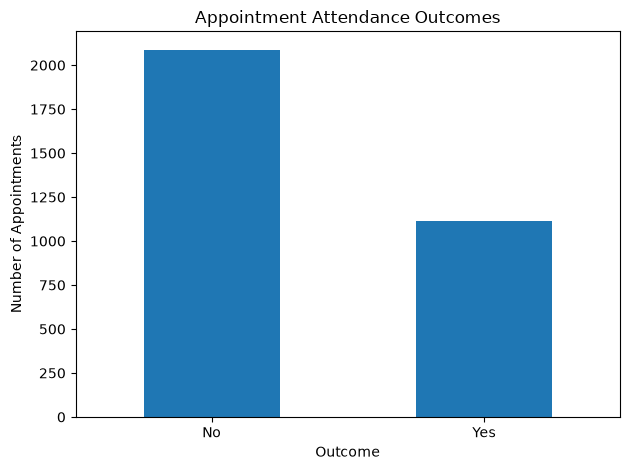

In [9]:
no_show_counts.plot(
    kind="bar",
    title="Appointment Attendance Outcomes"
)

plt.xlabel("Outcome")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**•	What is the main pattern shown in the chart?**

Attended appointments clearly outnumber missed ones, roughly two to one. But the
missed bar is still large. Over a thousand wasted slots is a real operational
problem, not a small one.

**•	Why is a chart useful even when counts are already available?**

The chart shows the size of the gap immediately, without the reader having to do
any arithmetic. That matters when the audience is a clinic administrator rather
than an analyst.

In [10]:
print("Appointment types:")
print(clinic["AppointmentType"].value_counts())

print("Insurance types:")
print(clinic["InsuranceType"].value_counts())

print("Time slots:")
print(clinic["TimeSlot"].value_counts())

print("Reminder status:")
print(clinic["ReminderSent"].value_counts())

Appointment types:
AppointmentType
Primary Care     1390
Follow-Up         900
Cardiology        512
Endocrinology     398
Name: count, dtype: int64
Insurance types:
InsuranceType
Medicare    1327
Private      966
Medicaid     675
Self-Pay     232
Name: count, dtype: int64
Time slots:
TimeSlot
Morning           1335
Afternoon         1236
Late Afternoon     629
Name: count, dtype: int64
Reminder status:
ReminderSent
Yes    2621
No      579
Name: count, dtype: int64


**•	Which appointment type is most common?** Primary Care, with 1,390 appointments.

**•	Which insurance type is most common?** Medicare, with 1,327.

**•	Which time slot is least common?** Late Afternoon, with 629 appointments,
compared to 1,335 in the morning and 1,236 in the afternoon.

**•	Why should group size be considered before interpreting a rate?**

A rate from a small group is unstable. Self-Pay only has 232 appointments, so a few
patients can shift its percentage noticeably, while the same change in Medicare's
1,327 would barely show. Small groups also tend to produce the most extreme-looking
rates by chance, which is why the count is reported next to every rate below.

---
# Part 3 — Exploratory Analytics

### Compare no-show rates by reminder status

In [11]:
insurance_summary = (
    clinic
    .groupby("InsuranceType")
    .agg(
        NumberOfAppointments=("AppointmentID", "count"),
        NoShowRate=("NoShowFlag", "mean")
    )
)
print(insurance_summary)

insurance_summary["NoShowRatePercent"] = (
    insurance_summary["NoShowRate"] * 100
).round(1)
print(insurance_summary)

insurance_summary.sort_values(
    "NoShowRatePercent",
    ascending=False
)

               NumberOfAppointments  NoShowRate
InsuranceType                                  
Medicaid                        675    0.438519
Medicare                       1327    0.325546
Private                         966    0.305383
Self-Pay                        232    0.383621
               NumberOfAppointments  NoShowRate  NoShowRatePercent
InsuranceType                                                     
Medicaid                        675    0.438519               43.9
Medicare                       1327    0.325546               32.6
Private                         966    0.305383               30.5
Self-Pay                        232    0.383621               38.4


,NumberOfAppointments,NoShowRate,NoShowRatePercent
InsuranceType,,,
Medicaid,675,0.438519,43.9
Self-Pay,232,0.383621,38.4
Medicare,1327,0.325546,32.6
Private,966,0.305383,30.5


*** 

**•	What is the no-show rate when a reminder was sent?** - 31.8% (2,621 appointments).

**•	What is the rate when no reminder was sent?** - 48.0% (579 appointments).

**•	Do reminders appear associated with attendance?**

Yes. The gap is 16.2 percentage points, the largest single-variable difference in
the dataset.

**•	Why does this comparison not prove that reminders caused the difference?**

The groups weren't randomly assigned — the clinic decided who got a reminder, and
that decision may line up with the same things that affect attendance. If reminders
only go to patients with a working phone number on file, then the no-reminder group
is already the harder-to-reach group. Proving cause would need a randomized trial.

### Compare no-show rates by insurance type

In [12]:
insurance_summary = (
    clinic
    .groupby("InsuranceType")
    .agg(
        NumberOfAppointments=("AppointmentID", "count"),
        NoShowRate=("NoShowFlag", "mean")
    )
)
print(insurance_summary)

insurance_summary["NoShowRatePercent"] = (
    insurance_summary["NoShowRate"] * 100
).round(1)
print(insurance_summary)

insurance_summary.sort_values(
    "NoShowRatePercent",
    ascending=False
)

               NumberOfAppointments  NoShowRate
InsuranceType                                  
Medicaid                        675    0.438519
Medicare                       1327    0.325546
Private                         966    0.305383
Self-Pay                        232    0.383621
               NumberOfAppointments  NoShowRate  NoShowRatePercent
InsuranceType                                                     
Medicaid                        675    0.438519               43.9
Medicare                       1327    0.325546               32.6
Private                         966    0.305383               30.5
Self-Pay                        232    0.383621               38.4


,NumberOfAppointments,NoShowRate,NoShowRatePercent
InsuranceType,,,
Medicaid,675,0.438519,43.9
Self-Pay,232,0.383621,38.4
Medicare,1327,0.325546,32.6
Private,966,0.305383,30.5


***

**•	Which group has the highest no-show rate?** - Medicaid, at 43.9%.

**•	Which group has the lowest?** - Private, at 30.5%.

**•	How many records are in each group?**
Medicare 1,327, Private 966, Medicaid 675, Self-Pay 232.

**•	What social or operational factors might help explain the differences?**
Insurance type here is really standing in for economic circumstance. Medicaid and
Self-Pay patients are more likely to face the practical barriers behind a missed
appointment. Hourly work where leaving early means lost pay, no car, childcare
that can't be moved. Self-Pay also adds a direct cost at the visit itself. The
pattern points toward removing barriers rather than just sending more reminders.

### Compare no-show rates by time slot

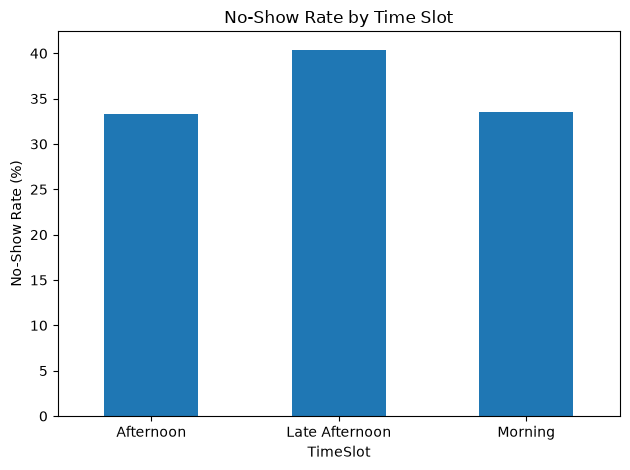

In [13]:
time_summary = (
    clinic.groupby("TimeSlot")
    .agg(
        NumberOfAppointments=("AppointmentID", "count"),
        NoShowRate=("NoShowFlag", "mean")
    )
)

time_summary["NoShowRatePercent"] = (time_summary["NoShowRate"] * 100).round(1)

time_summary

time_summary["NoShowRatePercent"].plot(
    kind="bar",
    title="No-Show Rate by Time Slot"
)
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**•	Which time slot has the highest no-show rate?**
Late Afternoon, at 40.4%. Morning (33.5%) and Afternoon (33.3%) are nearly the same
as each other and about 7 points lower.

**•	What operational explanation might account for this pattern?**
Late afternoon runs into the end of the working day — traffic, school pickup, and
whatever else has gone wrong since morning. A morning appointment is easier to
protect because the day hasn't had a chance to interfere yet.

**•	Would you recommend changing the clinic schedule based only on this result? Why or why not?**
No, not from this alone. We don't know if the late slot is actually the problem or
if the patients who book it were already more likely to miss anyway. And those
slots might be the only ones that work for people who can't get away from work
earlier in the day, so cutting them could end up making things worse.

***

### Compare scheduling lead time for attended and missed appointments

In [14]:
lead_time_comparison = (
    clinic
    .groupby("NoShow")["SchedulingLeadDays"]
    .mean()
    .round(1)
)

lead_time_comparison


NoShow
No     27.6
Yes    35.7
Name: SchedulingLeadDays, dtype: float64

**•	What is the average lead time for attended appointments?**
Average lead time for attended appointments: 27.6 days.

**•	What is the average for missed appointments?**
Average for missed appointments:** 35.7 days.

**•	What might explain the difference?**
Appointments booked further out are missed more often. The longer the wait, the more
chance something changes — the patient's schedule shifts, the problem resolves on
its own, or they simply forget a commitment made two months earlier. Contact details
can also go stale in that time, so the reminder never reaches them.

**•	Suggest one scheduling policy the clinic could test.**
For anything booked more than about a month out, add a confirmation call or message
around a week before the visit and ask the patient to confirm. That turns an old
booking into a fresh commitment and frees up the slot early if they can't make it.

---
### Compare distance for attended and missed appointments

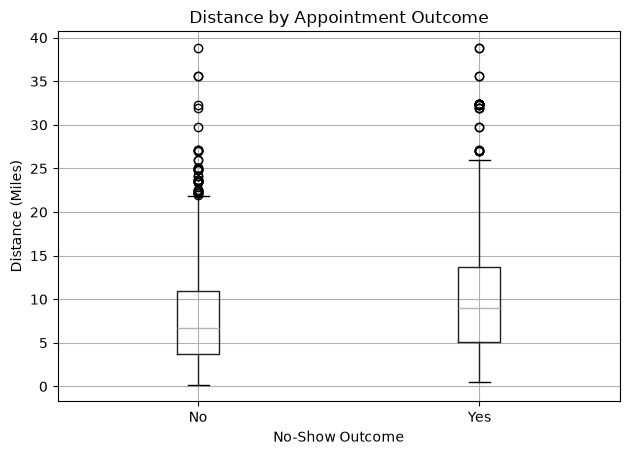

In [15]:
distance_comparison = (
    clinic
    .groupby("NoShow")["DistanceMiles"]
    .mean()
    .round(1)
)

distance_comparison
clinic.boxplot(
    column="DistanceMiles",
    by="NoShow"
)
plt.title("Distance by Appointment Outcome")
plt.suptitle("")
plt.xlabel("No-Show Outcome")
plt.ylabel("Distance (Miles)")
plt.tight_layout()
plt.show()

**•	Which group travels farther on average?**
The no-show group, at 10.2 miles compared to 7.8 for those who attended.

**•	Does the boxplot show substantial overlap?**
Yes, a lot. Both boxes cover much of the same range and both reach the same maximum
around 39 miles. The distributions are shifted, not separated. So distance tells us
something at the group level but doesn't predict much for any individual patient —
plenty of people travel far and still show up. This is part of why a model using
several variables together is needed.


**•	What transportation-related intervention might the clinic consider?**
Offer transport help to patients living farther out, like bus passes or a rideshare
voucher, and prioritize them for telehealth when the visit doesn't need a physical
exam. Follow-ups and medication reviews would work well that way.

### Examine the effect of previous appointment history

In [16]:
history_comparison = (
    clinic
    .groupby("NoShow")[[
        "PreviousNoShows",
        "PreviousCompletedVisits"
    ]]
    .mean()
    .round(2)
)

history_comparison

,PreviousNoShows,PreviousCompletedVisits
NoShow,,
No,0.52,1.38
Yes,1.00,1.14


**•	How do previous no-shows differ between the groups?**
Patients who missed averaged 1.00 previous no-shows compared to 0.52 for those who
attended — nearly double.

**•	How do previous completed visits differ?**
The difference is much smaller and in the expected direction: 1.14 for the no-show
group versus 1.38 for those who attended.

**•	Which historical variable appears more informative?**
**PreviousNoShows**, since it nearly doubles between the two groups while completed
visits only shift by about 0.24.

**•	Could relying heavily on past behavior create fairness concerns? Explain.**
Yes. Someone who missed appointments before probably still has the same barriers, like
transport, work hours, or childcare. So the model is really picking up on hardship and
treating it as unreliability. Whether that's a problem depends on what the clinic
does with the flag. Using it to offer extra help is reasonable; using it to
deprioritize those patients would just make things worse for the people who already
have the hardest time getting in.

--- 
### Examine chronic conditions together

In [17]:
condition_summary = (
    clinic
    .groupby(["Diabetes", "Hypertension"])
    .agg(
        NumberOfAppointments=("AppointmentID", "count"),
        NoShowRate=("NoShowFlag", "mean")
    )
)

condition_summary["NoShowRatePercent"] = (
    condition_summary["NoShowRate"] * 100
).round(1)

condition_summary.sort_values(
    "NoShowRatePercent",
    ascending=False
)

NumberOfAppointments  NoShowRate  NoShowRatePercent
Diabetes Hypertension                                                     
No       Yes                            796    0.368090               36.8
Yes      No                             339    0.365782               36.6
         Yes                            139    0.359712               36.0
No       No                            1926    0.334891               33.5

**•	Which combination has the highest no-show rate?**

Hypertension without diabetes, at 36.8%, though diabetes without hypertension is
essentially the same at 36.6%.

**•	Which has the lowest?**
Neither condition, at 33.5%.

**•	Do the differences appear large?**

No. The whole range is only about 3 points, much smaller than the 16-point gap for
reminders. The "both conditions" group also has just 139 appointments, so its
position in the ranking doesn't mean much. Chronic conditions look close to
irrelevant for predicting attendance here.

**•	Why might clinical need and attendance behavior not move in the same direction?**

They're driven by different things. Clinical need comes from the illness itself,
while attendance depends on whether the patient can actually get there. Someone with
poorly controlled diabetes may need the visit most and still have the hardest time
making it, since the same circumstances can affect both. Sicker patients may also be
too unwell to travel or already juggling appointments across several specialties.

---
### Perform one student-designed exploratory analysis
**Variables selected:** `PreferredContact` and `ReminderSent`.

**Question:** Does a reminder work better when it goes through the channel the
patient prefers? If some channels work better than others, the clinic can change how
it sends reminders rather than just sending more of them.

In [18]:
contact_summary = (
    clinic
    .groupby(["PreferredContact", "ReminderSent"])
    .agg(
        NumberOfAppointments=("AppointmentID", "count"),
        NoShowRate=("NoShowFlag", "mean")
    )
)

contact_summary["NoShowRatePercent"] = (contact_summary["NoShowRate"] * 100).round(1)

contact_summary.sort_values("NoShowRatePercent", ascending=False)

,,NumberOfAppointments,NoShowRate,NoShowRatePercent
PreferredContact,ReminderSent,,,
Email,No,116,0.534483,53.4
Text,No,270,0.488889,48.9
Phone,No,193,0.435233,43.5
Email,Yes,432,0.354167,35.4
Text,Yes,1334,0.317841,31.8
Phone,Yes,855,0.300585,30.1


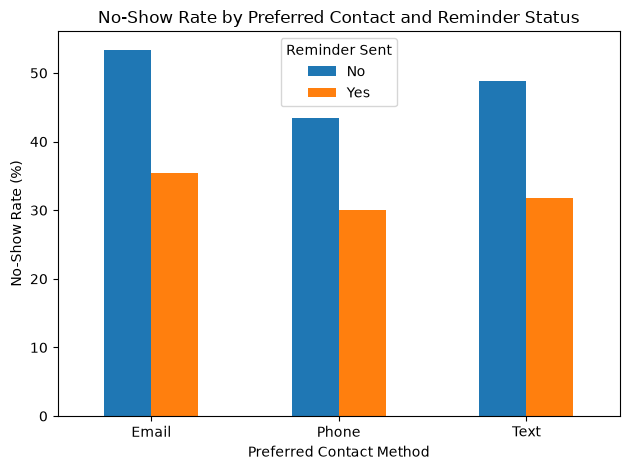

In [19]:
plot_data = contact_summary["NoShowRatePercent"].unstack("ReminderSent")

plot_data.plot(kind="bar", title="No-Show Rate by Preferred Contact and Reminder Status")
plt.ylabel("No-Show Rate (%)")
plt.xlabel("Preferred Contact Method")
plt.xticks(rotation=0)
plt.legend(title="Reminder Sent")
plt.tight_layout()
plt.show()

**Interpretation.**

Every contact group does better with a reminder than without one. Among those that
got a reminder, phone is lowest at 30.1%, then text at 31.8%, and email highest at
35.4%, and the same ordering holds in the no-reminder rows. Email without a reminder
is the worst cell at 53.4%, though it covers only 116 appointments so it shouldn't
be read too strongly. Overall the gap between getting a reminder and not getting one
is much bigger than the gap between channels, so making sure everyone gets some
reminder matters more than picking the best one..


**•	Which variables did you select?**

`PreferredContact` and `ReminderSent`.

**•	Why did you select them?**

They hadn't been looked at together, and unlike most pairings this one points to
something the clinic can actually change at almost no cost — how it sends reminders,
not just how many.

**•	What pattern did you find?**

Every contact group does better with a reminder than without one. Among those that
got a reminder, phone is lowest at 30.1%, text is 31.8%, and email is highest at
35.4%. The same ordering shows up in the no-reminder rows, where email reaches 53.4%.
The gap between getting a reminder and not getting one is much bigger than the gap
between channels, so making sure everyone gets a reminder matters more than which
channel it goes through.

**•	What additional data would help explain the pattern?**

Whether the reminder was actually delivered and opened. Right now a bounced email and
a read one both count as `ReminderSent = Yes`, so the variable measures what the
clinic sent, not what the patient received.

---
# Part 4 — Parallel Descriptive Analytics with SQL

These queries were run in MySQL from WSL, not in this notebook. The SQL and its
output are recorded below.

Connected with:

    sudo mysql --local-infile=1
    SET GLOBAL local_infile = ON; are recorded below.

Connected

### Create and select the database

```sql
CREATE DATABASE IF NOT EXISTS clinic_db;
USE clinic_db;
SELECT DATABASE();
```

Output: `clinic_db`

**What database is currently selected?**

`clinic_db`. Before the `USE` statement, `SELECT DATABASE()` returns `NULL`.

**Why must `USE clinic_db` be executed before creating the tables?**

`CREATE TABLE` builds the table inside whichever database is currently active. Without
`USE`, there isn't one, and MySQL returns an error. If a different database happened to
be selected, the tables would end up in the wrong place.

### Create the patient and appointment tables

```sql
DROP TABLE IF EXISTS clinic_appointments;
DROP TABLE IF EXISTS clinic_patients;

CREATE TABLE clinic_patients (
    PatientID VARCHAR(10) PRIMARY KEY,
    Age INT,
    InsuranceType VARCHAR(30),
    DistanceMiles DECIMAL(6,1),
    Diabetes VARCHAR(3),
    Hypertension VARCHAR(3),
    PreferredContact VARCHAR(20)
);

CREATE TABLE clinic_appointments (
    AppointmentID VARCHAR(10) PRIMARY KEY,
    PatientID VARCHAR(10),
    AppointmentDate DATE,
    AppointmentType VARCHAR(50),
    TimeSlot VARCHAR(30),
    SchedulingLeadDays INT,
    ReminderSent VARCHAR(3),
    WeatherCondition VARCHAR(30),
    PreviousNoShows INT,
    PreviousCompletedVisits INT,
    NoShow VARCHAR(3)
);

DESCRIBE clinic_patients;
DESCRIBE clinic_appointments;
```

Output: 7 columns in `clinic_patients`, 11 in `clinic_appointments`.

**What is the primary key of each table?**

`PatientID` for `clinic_patients` and `AppointmentID` for `clinic_appointments`.

**Which column connects the two tables?**

`PatientID` — the primary key in one table and a foreign key in the other.

**Why can `PatientID` appear many times in `clinic_appointments`?**

Because it isn't the primary key there. One patient books many visits, so the same ID
repeats on every appointment belonging to that person.

**Why is the appointment table created before it is dropped but after the patient table is created?**

The appointment table depends on the patient table through `PatientID`, so the order has
to respect that. Dropping runs child first, creating runs parent first.

### Load the CSV data into MySQL

```sql
LOAD DATA LOCAL INFILE '/mnt/c/Users/sshampa/Desktop/MS in ECE/Summer_2026/Introduction_to_Big_Data_Analysis/Assignment/Final_Project/clinic_patients.csv'
INTO TABLE clinic_patients
FIELDS TERMINATED BY ','
OPTIONALLY ENCLOSED BY '"'
LINES TERMINATED BY '\r\n'
IGNORE 1 ROWS;

LOAD DATA LOCAL INFILE '/mnt/c/Users/sshampa/Desktop/MS in ECE/Summer_2026/Introduction_to_Big_Data_Analysis/Assignment/Final_Project/clinic_appointments.csv'
INTO TABLE clinic_appointments
FIELDS TERMINATED BY ','
OPTIONALLY ENCLOSED BY '"'
LINES TERMINATED BY '\r\n'
IGNORE 1 ROWS;
```

Output: 800 records loaded into `clinic_patients` and 3,200 into `clinic_appointments`,
both with 0 warnings.

Note: these CSV files use Windows line endings, so `LINES TERMINATED BY '\r\n'` is needed
instead of `'\n'`. With `'\n'` the carriage return stays attached to the last column, so
`NoShow` loads as `'Yes\r'` and every rate calculated from it returns 0% without any
error message.

**•	Why is IGNORE 1 ROWS included?**

The first line of each file is the header row, not data. Without it MySQL would try to
insert the column names as an actual record.

**•	Why should a complete file path be used?**

A relative path is resolved from wherever the `mysql` client was started, which usually
isn't the folder holding the CSVs. The full path removes that ambiguity.

**•	What does FIELDS TERMINATED BY ',' specify?**

The character separating one column from the next within each line.

**•	What does OPTIONALLY ENCLOSED BY '"' allow MySQL to handle?**

Values wrapped in double quotes. It tells MySQL to treat the quotes as delimiters rather
than data, so a comma inside a quoted value isn't mistaken for a column break. The word
*optionally* means unquoted values load normally too.

### Verify that the tables were loaded correctly

```sql
SHOW TABLES;

SELECT COUNT(*) AS NumberOfPatients FROM clinic_patients;
SELECT COUNT(*) AS NumberOfAppointments FROM clinic_appointments;

SELECT * FROM clinic_patients LIMIT 5;
SELECT * FROM clinic_appointments LIMIT 5;
```

Output: 800 patients and 3,200 appointments.

**How many patient records were loaded?** 800.

**How many appointment records were loaded?** 3,200.

**Why are there more appointment rows than patient rows?**

Each patient books several visits, so one patient produces multiple appointment rows.

**Are the first five records consistent with the earlier Python previews?**

Yes. The patient rows show P0001 through P0005 with the same ages, insurance types and
distances as `patients.head()`, and the appointment rows match `appointments.head()`,
starting with A00001 for patient P0065.

### Join the patient and appointment tables

```sql
SELECT
    a.AppointmentID,
    a.PatientID,
    a.AppointmentType,
    a.TimeSlot,
    a.SchedulingLeadDays,
    a.ReminderSent,
    a.PreviousNoShows,
    a.NoShow,
    p.Age,
    p.InsuranceType,
    p.DistanceMiles,
    p.Diabetes,
    p.Hypertension,
    p.PreferredContact
FROM clinic_appointments AS a
INNER JOIN clinic_patients AS p
    ON a.PatientID = p.PatientID
LIMIT 10;
```

Output: 10 rows, each appointment now carrying its patient's details.

**Which columns are used in the JOIN condition?**

`a.PatientID` and `p.PatientID`.

**What is the purpose of the aliases `a` and `p`?**

They shorten the column references and remove ambiguity. `PatientID` exists in both
tables, so without an alias MySQL wouldn't know which one is meant.

**Why should the complete join contain approximately the same number of rows as `clinic_appointments`?**

Each appointment matches exactly one patient, so the join adds columns rather than rows.
More rows would mean `PatientID` was duplicated in the patient table.

**How is `INNER JOIN` similar to the Pandas merge used earlier?**

Both match rows from two tables on a shared key and combine their columns.
`ON a.PatientID = p.PatientID` does the same job as `on="PatientID"`. The difference is
that the merge used `how="left"`, which keeps every appointment regardless, while
`INNER JOIN` keeps only rows that match on both sides. Here the results are the same
because every appointment has a valid patient.

### Calculate overall descriptive statistics with MySQL

```sql
SELECT
    COUNT(*) AS NumberOfAppointments,
    COUNT(DISTINCT a.PatientID) AS NumberOfPatients,
    ROUND(AVG(p.Age), 1) AS AverageAge,
    ROUND(AVG(p.DistanceMiles), 1) AS AverageDistanceMiles,
    ROUND(AVG(a.SchedulingLeadDays), 1) AS AverageLeadDays,
    ROUND(
        100.0 * AVG(
            CASE
                WHEN a.NoShow = 'Yes' THEN 1.0
                ELSE 0.0
            END
        ),
        1
    ) AS NoShowRatePercent
FROM clinic_appointments AS a
INNER JOIN clinic_patients AS p
    ON a.PatientID = p.PatientID;
```

Output: 3,200 appointments, 786 patients, average age 53.3, average distance 8.7 miles,
average lead time 30.4 days, no-show rate 34.8%.

**What does `COUNT(*)` calculate?**

The number of rows in the result, which here is 3,200 appointments.

**Why is `COUNT(DISTINCT a.PatientID)` different from `COUNT(*)`?**

Because patients repeat across rows. `COUNT(*)` counts appointments while
`COUNT(DISTINCT a.PatientID)` counts people, and 786 patients account for those 3,200
appointments. It's also lower than the 800 rows in `clinic_patients` because the inner
join leaves out the 14 patients who never booked a visit.

**How does `CASE` convert Yes/No values into a rate?**

MySQL can't average text, so `CASE` turns each value into a number, 1 for `'Yes'` and 0
for `'No'`. The average of that column is the proportion of no-shows, and multiplying by
100 makes it a percentage. It's the same idea as the `NoShowFlag` column in Part 2.

**Do the MySQL results match the Python descriptive results?**

Yes, all of them. Average age, distance, lead time and the 34.8% no-show rate are the
same as the `describe()` output and the overall rate from Part 2.

### Compare no-show rates by reminder status

```sql
SELECT
    ReminderSent,
    COUNT(*) AS NumberOfAppointments,
    ROUND(
        100.0 * AVG(
            CASE
                WHEN NoShow = 'Yes' THEN 1.0
                ELSE 0.0
            END
        ),
        1
    ) AS NoShowRatePercent
FROM clinic_appointments
GROUP BY ReminderSent
ORDER BY NoShowRatePercent DESC;
```

Output: No reminder — 579 appointments, 48.0%. Reminder sent — 2,621 appointments, 31.8%.

**Which reminder group has the higher no-show rate?**

The group that got no reminder, at 48.0% compared to 31.8%.

**What does `GROUP BY` do?**

It splits the rows into groups by the values in `ReminderSent` and calculates the
aggregates separately for each one, so you get a rate per group instead of a single
overall rate. It works the same way as `groupby()` in pandas.

**What does `ORDER BY NoShowRatePercent DESC` do?**

Sorts the results by the calculated rate from highest to lowest, so the group with the
worst attendance appears first.

**Does the MySQL conclusion agree with the Python conclusion?**

Yes, the counts and rates are identical. No join was needed here since both columns are
in the appointment table.

### Compare no-show rates by appointment type

```sql
SELECT
    AppointmentType,
    COUNT(*) AS NumberOfAppointments,
    ROUND(
        100.0 * AVG(
            CASE
                WHEN NoShow = 'Yes' THEN 1.0
                ELSE 0.0
            END
        ),
        1
    ) AS NoShowRatePercent
FROM clinic_appointments
GROUP BY AppointmentType
ORDER BY NoShowRatePercent DESC;
```

Output: Follow-Up 36.6% (900), Cardiology 35.5% (512), Primary Care 33.7% (1,390),
Endocrinology 33.2% (398).

**Which appointment type has the highest no-show rate?** Follow-Up, at 36.6%.

**Which has the lowest?** Endocrinology, at 33.2%.

**Why should the number of appointments in each group be considered?**

The rates only span about 3 points, but the group sizes vary a lot. Endocrinology's rate
comes from 398 appointments while Primary Care's comes from 1,390, so the smaller groups
are much more affected by chance. Volume also matters for what the clinic should focus
on — Primary Care's 33.7% works out to 469 missed appointments, far more than any other
type despite the lower rate.

### Compare attended and missed appointments

```sql
SELECT
    a.NoShow,
    COUNT(*) AS NumberOfAppointments,
    ROUND(AVG(a.SchedulingLeadDays), 1) AS AverageLeadDays,
    ROUND(AVG(p.DistanceMiles), 1) AS AverageDistanceMiles,
    ROUND(AVG(a.PreviousNoShows), 2) AS AveragePreviousNoShows,
    ROUND(AVG(a.PreviousCompletedVisits), 2) AS AverageCompletedVisits
FROM clinic_appointments AS a
INNER JOIN clinic_patients AS p
    ON a.PatientID = p.PatientID
GROUP BY a.NoShow
ORDER BY a.NoShow;
```

Output: Attended — 2,088 appointments, 27.6 lead days, 7.8 miles, 0.52 previous no-shows,
1.38 completed visits. Missed — 1,112 appointments, 35.7 lead days, 10.2 miles, 1.00
previous no-shows, 1.14 completed visits.

**Which outcome group has the longer average scheduling lead time?**

The no-show group, at 35.7 days compared to 27.6.

**Which group lives farther from the clinic on average?**

Also the no-show group, at 10.2 miles compared to 7.8.

**How strongly do previous no-shows differ?**

1.00 for the missed group against 0.52 for the attended one, close to
double.

**Which result appears most useful for predicting future no-shows?**

`PreviousNoShows`, since it shows the biggest relative gap between the two groups.
Scheduling lead time is next, and it has the advantage of being known when the
appointment is booked.

**Do the MySQL and Python results agree?**

Yes, every figure matches the comparisons from Part 3.

### Compare no-show rates by insurance type

```sql
SELECT
    p.InsuranceType,
    COUNT(*) AS NumberOfAppointments,
    ROUND(
        100.0 * AVG(
            CASE
                WHEN a.NoShow = 'Yes' THEN 1.0
                ELSE 0.0
            END
        ),
        1
    ) AS NoShowRatePercent
FROM clinic_appointments AS a
INNER JOIN clinic_patients AS p
    ON a.PatientID = p.PatientID
GROUP BY p.InsuranceType
ORDER BY NoShowRatePercent DESC;
```

Output: Medicaid 43.9% (675), Self-Pay 38.4% (232), Medicare 32.6% (1,327), Private
30.5% (966).

**Which insurance group has the highest no-show rate?**

Medicaid, at 43.9%, which is over 13 points above Private at 30.5%.

**Why is a JOIN required for this query?**

The two columns live in different tables. `InsuranceType` belongs to the patient and
`NoShow` belongs to the appointment, so neither table can answer this on its own. The
join brings them together first.

**Does this result match the Python analysis?**

Yes, the same four rates in the same order as the `insurance_summary` table in Part 3.

---
# Part 5 — Prepare the Data for Predictive Analysis

In [20]:
feature_columns = [
    "Age",
    "InsuranceType",
    "DistanceMiles",
    "Diabetes",
    "Hypertension",
    "PreferredContact",
    "AppointmentType",
    "TimeSlot",
    "SchedulingLeadDays",
    "ReminderSent",
    "WeatherCondition",
    "PreviousNoShows",
    "PreviousCompletedVisits"
]

X = clinic[feature_columns]
y = clinic["NoShowFlag"]

**What does `X` contain?**

The 13 variables the model uses to make its prediction — things like age, insurance,
distance, appointment type, time slot, lead days, and past attendance. All of these are
known before the appointment happens.

**What does `y` contain?**

The answer we're trying to predict, `NoShowFlag`, which says whether each appointment
was missed.

**Why are `PatientID` and `AppointmentID` excluded?**

They're just ID numbers and don't tell us anything useful. If we included them the model
would end up memorizing specific rows instead of learning a real pattern.

**Why is `NoShow` excluded from `X`?**

It's the same thing as `NoShowFlag`, just written as text. Giving it to the model would
be giving away the answer, and it wouldn't help with a future appointment where we don't
know the outcome yet.

**Is this a classification or regression problem? Explain.**

Classification, because the outcome is one of two categories rather than a number on a
scale. That's why we use logistic regression here and check the results with a confusion
matrix.

### Split the data into training and testing sets

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))
print("Training no-show rate:", round(y_train.mean(), 3))
print("Testing no-show rate:", round(y_test.mean(), 3))


Training records: 2400
Testing records: 800
Training no-show rate: 0.348
Testing no-show rate: 0.348


**•	What percentage of records is used for testing?**

25%, which is 800 appointments out of 3,200. The other 2,400 are used for training.

**•	Why should the model be evaluated on records it did not study?**

Because a model can do well on data it has already seen just by memorizing it. Testing on
records it hasn't seen shows whether it actually learned something useful, and it matches
the real situation where next week's appointments haven't happened yet.

**•	What does stratify=y help preserve?**

The balance between the two outcomes. It makes sure the training and testing sets both
have about the same no-show rate as the full dataset — here both came out at 0.348 — so
the model isn't trained on one balance and tested against a different one.

### Encode categorical variables and scale numerical variables

In [22]:
from sklearn.preprocessing import StandardScaler

numerical_features = [
    "Age",
    "DistanceMiles",
    "SchedulingLeadDays",
    "PreviousNoShows",
    "PreviousCompletedVisits"
]

categorical_features = [
    "InsuranceType",
    "Diabetes",
    "Hypertension",
    "PreferredContact",
    "AppointmentType",
    "TimeSlot",
    "ReminderSent",
    "WeatherCondition"
]

X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_features,
    drop_first=False,
    dtype=int
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_features,
    drop_first=False,
    dtype=int
)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

scaler = StandardScaler()

X_train_encoded[numerical_features] = scaler.fit_transform(
    X_train_encoded[numerical_features]
)

X_test_encoded[numerical_features] = scaler.transform(
    X_test_encoded[numerical_features]
)

print("Training shape:", X_train_encoded.shape)
print("Testing shape:", X_test_encoded.shape)
X_train_encoded.head()

Training shape: (2400, 28)
Testing shape: (800, 28)


,Age,DistanceMiles,SchedulingLeadDays,PreviousNoShows,PreviousCompletedVisits,InsuranceType_Medicaid,InsuranceType_Medicare,InsuranceType_Private,InsuranceType_Self-Pay,Diabetes_No,...,AppointmentType_Follow-Up,AppointmentType_Primary Care,TimeSlot_Afternoon,TimeSlot_Late Afternoon,TimeSlot_Morning,ReminderSent_No,ReminderSent_Yes,WeatherCondition_Clear,WeatherCondition_Rain,WeatherCondition_Severe Weather
2109,1.180897,1.463183,0.730212,-0.646319,1.873968,0,0,1,0,1,...,1,0,1,0,0,0,1,1,0,0
92,1.277538,-0.650877,1.130602,-0.646319,-0.901424,0,1,0,0,1,...,1,0,1,0,0,0,1,1,0,0
692,-1.718343,-0.231421,0.615815,0.317737,-0.901424,1,0,0,0,1,...,0,0,0,0,1,0,1,1,0,0
1363,0.601049,-0.348869,0.101027,-0.646319,0.486272,0,1,0,0,1,...,0,1,0,1,0,0,1,1,0,0
529,-1.476740,-0.248199,0.387020,-0.646319,-0.207576,0,0,1,0,1,...,1,0,1,0,0,1,0,1,0,0


**•	Why must text categories be converted to numbers?**
The model does math on its inputs, and it can't multiply a word like "Medicaid". Just
replacing the categories with numbers like 1, 2, 3 wouldn't work either, because that
would suggest one insurance type is bigger than another when they're just different.

**•	What does pd.get_dummies() create?**
A separate 0/1 column for each category. `InsuranceType` turns into four columns, one per
type, with a 1 in whichever one applies. This is why the 13 features became 28 columns.

**•	Why must test columns match training columns?**
The model learned one value for each column in a set order, so the test set has to have
the same columns in the same order. `reindex` handles this by filling in any missing
column with zeros.

**•	Why is the scaler fitted only on training data?**
Because the test set is supposed to stand in for future data we haven't seen yet. If the
scaler used the test data too, information about it would leak into the training process
and the results would look better than they really are.

---
# Part 6 — Train the Predictive Model

### Train a logistic regression model

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(
    X_train_encoded,
    y_train
)

print("Model training complete.")

Model training complete.


**•	What algorithm is used?**
Logistic regression. It combines the input features into a single score and converts that
into a probability between 0 and 1.

**•	What does model.fit() do conceptually?**
It goes through the 2,400 training appointments and works out how much weight to give each
feature so the predictions match what actually happened. `class_weight="balanced"` tells it
to treat both outcomes as equally important, otherwise it would lean toward predicting
"attended" for almost everyone since that's 65% of the data.

**•	What information does the model study?**
The 28 encoded features for each training appointment along with whether that appointment
was actually missed. It never sees the test appointments.

**•	Does training guarantee correct future predictions? Explain.**
No. People aren't predictable, and two patients with the same details can make different
choices. The model also only knows the variables it was given, and the real reasons
someone misses an appointment — a sick child, no ride, a work conflict — aren't in this
data at all.

### Generate predicted classes and probabilities

In [24]:
predicted_classes = model.predict(
    X_test_encoded
)

predicted_probabilities = model.predict_proba(
    X_test_encoded
)[:, 1]

results = X_test.copy()
results["ActualNoShow"] = y_test
results["PredictedNoShow"] = predicted_classes
results["PredictedProbability"] = predicted_probabilities
results["PredictedProbabilityPercent"] = (
    results["PredictedProbability"] * 100
).round(1)

results.head(10)

,Age,InsuranceType,DistanceMiles,Diabetes,Hypertension,PreferredContact,AppointmentType,TimeSlot,SchedulingLeadDays,ReminderSent,WeatherCondition,PreviousNoShows,PreviousCompletedVisits,ActualNoShow,PredictedNoShow,PredictedProbability,PredictedProbabilityPercent
2855,66,Private,11.3,No,Yes,Email,Endocrinology,Late Afternoon,12,Yes,Rain,3,1,0,1,0.653787,65.4
2228,18,Private,4.6,No,No,Email,Primary Care,Late Afternoon,11,No,Clear,1,3,0,0,0.419965,42.0
3010,79,Medicare,17.8,No,No,Text,Primary Care,Afternoon,30,Yes,Clear,5,1,0,1,0.884973,88.5
2807,76,Private,3.2,No,No,Text,Cardiology,Morning,5,No,Clear,1,3,0,0,0.298259,29.8
1717,86,Medicare,12.9,Yes,No,Text,Endocrinology,Morning,43,Yes,Clear,0,3,1,0,0.476994,47.7
2705,19,Medicaid,8.1,No,Yes,Phone,Primary Care,Morning,47,Yes,Clear,2,1,1,1,0.663560,66.4
742,78,Medicare,16.7,No,Yes,Phone,Primary Care,Morning,8,Yes,Clear,0,0,0,0,0.293113,29.3
2044,87,Medicare,7.2,No,No,Phone,Follow-Up,Afternoon,9,No,Severe Weather,0,2,0,0,0.428250,42.8
787,73,Medicare,16.1,No,No,Text,Primary Care,Afternoon,8,Yes,Clear,0,0,0,0,0.328041,32.8
2061,70,Medicare,9.4,No,Yes,Phone,Follow-Up,Afternoon,40,No,Clear,0,2,0,1,0.543468,54.3


**•	What does PredictedProbability represent?**
The model's estimate of how likely that appointment is to be missed, on a 0 to 1 scale.
Across the test set the values range from about 7% to 96%, so the model does separate
low-risk from high-risk appointments.

**•	What is the difference between a probability of 0.72 and a predicted class of 1?**
The probability is the actual estimate, while the class is just that number turned into a
yes or no. An appointment at 0.72 and one at 0.51 both become class 1 even though one is
much riskier than the other, so the probability carries more information.

**•	Does 0.72 mean the patient will definitely miss the appointment?**
No. It means that among similar appointments, about 72% were missed and 28% were kept. It
describes a group, not a certainty about one person.

**•	What default threshold is normally used to convert probability into class?**
0.50. Anything at or above becomes class 1, anything below becomes class 0.

---
# Part 7 — Evaluate the Model
### Create and interpret a confusion matrix

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predicted_classes
)

confusion_table = pd.DataFrame(
    cm,
    index=["Actual: Attended", "Actual: No-Show"],
    columns=["Predicted: Attended", "Predicted: No-Show"]
)

confusion_table

,Predicted: Attended,Predicted: No-Show
Actual: Attended,343,179
Actual: No-Show,91,187


**•	Report the true negatives, false positives, false negatives, and true positives.**
Out of 800 test appointments: 343 true negatives, 179 false positives, 91 false negatives,
and 187 true positives. So the model caught 187 of the 278 appointments that were actually
missed.

**•	What does a false positive mean for clinic staff?**
The model flagged an appointment as risky but the patient came anyway. There were 179 of
these, which means about half the flagged appointments were false alarms. The cost is a
reminder call that wasn't needed.

**•	What does a false negative mean?**
The model expected the patient to attend and they didn't. There were 91 of these, so no
call was made and the slot was lost.

**•	Which error may waste staff time?**
False positives, since each one is a call placed to someone who was going to show up
anyway.

**•	Which error may cause the clinic to miss an opportunity to intervene?**
False negatives. These are the appointments that got missed without anyone reaching out
first, so the clinic loses the slot and the patient's care gets delayed.


---
# Part 8 — Use Predictions for Clinic Decision-Making
### Rank appointments by predicted risk

In [26]:
ranked_appointments = results.sort_values(
    by="PredictedProbability",
    ascending=False
)

high_risk_100 = ranked_appointments.head(100)

high_risk_100[[
    "Age",
    "InsuranceType",
    "DistanceMiles",
    "AppointmentType",
    "TimeSlot",
    "SchedulingLeadDays",
    "ReminderSent",
    "PreviousNoShows",
    "PredictedProbabilityPercent",
    "ActualNoShow"
]].head(20)

,Age,InsuranceType,DistanceMiles,AppointmentType,TimeSlot,SchedulingLeadDays,ReminderSent,PreviousNoShows,PredictedProbabilityPercent,ActualNoShow
2768,42,Medicare,32.4,Follow-Up,Afternoon,11,Yes,7,96.4,1
2960,79,Medicare,17.8,Primary Care,Afternoon,38,No,5,96.4,0
819,42,Medicare,32.4,Primary Care,Late Afternoon,59,Yes,2,96.0,1
1677,43,Self-Pay,16.3,Endocrinology,Late Afternoon,56,No,2,95.5,1
2690,54,Self-Pay,7.3,Primary Care,Morning,58,Yes,6,94.8,0
3096,79,Medicare,17.8,Follow-Up,Afternoon,53,Yes,5,93.8,0
157,45,Medicaid,32.3,Primary Care,Afternoon,48,No,0,93.6,1
2606,83,Medicare,11.0,Endocrinology,Afternoon,46,Yes,6,93.5,1
2873,62,Self-Pay,7.5,Cardiology,Morning,57,Yes,5,93.4,1
2184,21,Medicaid,19.7,Follow-Up,Late Afternoon,58,Yes,2,93.3,1


In [27]:
print("Highest predicted probability:",
      ranked_appointments["PredictedProbabilityPercent"].max(), "%")
print("Lowest probability in the top 100:",
      high_risk_100["PredictedProbabilityPercent"].min(), "%")
print("Appointments flagged at the 0.50 threshold:",
      int(results["PredictedNoShow"].sum()))

Highest predicted probability: 96.4 %
Lowest probability in the top 100: 74.0 %
Appointments flagged at the 0.50 threshold: 366


- **What is the highest predicted probability?**- 96.4%.

- **What is the lowest probability among the top 100?**- 74.0%, so every appointment on the call list is estimated at 74% risk or higher, compared
to an overall rate of 34.8%.

- **Why might ranking be more useful than a fixed threshold when staff capacity is exactly 100 calls?**

Because the threshold doesn't know how many calls the clinic can make. At the default 0.50
cutoff the model flags 366 appointments, which is far more than 100, so staff would have to
pick 100 of them with no way to tell which are riskiest. Ranking sorts by probability and
takes the top 100, so the list always matches capacity and the effort goes to the highest
risk appointments first. It also adjusts easily if capacity changes.

### Summarize the top 100 appointments

In [28]:
print("Average age:", round(high_risk_100["Age"].mean(), 1))
print("Average distance:", round(high_risk_100["DistanceMiles"].mean(), 1))
print("Average previous no-shows:", round(high_risk_100["PreviousNoShows"].mean(), 2))
print("Reminder sent percentage:", round((high_risk_100["ReminderSent"] == "Yes").mean() * 100, 1))
print("Actual no-show percentage:", round(high_risk_100["ActualNoShow"].mean() * 100, 1))

Average age: 55.0
Average distance: 14.5
Average previous no-shows: 1.81
Reminder sent percentage: 60.0
Actual no-show percentage: 61.0


- **How many of the top 100 actually missed their appointments?**

61 out of 100.

- **How does their no-show percentage compare with the overall rate?**

61.0% compared to 34.8% overall, so about 1.8 times higher. Calling 100 patients at random
would reach roughly 35 who were going to miss, while calling the top 100 from the model
reaches 61.

- **What characteristics are common in this group?**

They live farther away, 14.5 miles on average against 8.7 overall, book further ahead at
45.7 days against 30.4, and have more previous no-shows, 1.81 against 0.69. Medicaid and
Self-Pay patients are heavily represented. Average age is 55, basically the same as
everyone else, so age isn't really doing anything here. Notably 60% of this group already
got a reminder, so the standard reminder clearly isn't enough for them.

- **Does the group appear useful for targeted outreach? Explain.**

Yes. The same number of calls reaches almost twice as many at-risk patients as random
calling would, and the list fits the clinic's weekly capacity. The catch is that 39 of the
100 would have come anyway, so the calls should be an offer of help rather than anything
that puts pressure on the patient. The group also skews toward Medicaid and Self-Pay
patients living farther out, which is the group already facing the most difficulty getting
in, so the outreach needs to actually help them get there.

### Operational recommendation

The clinic should call the 100 highest-ranked appointments each week and keep sending
automated reminders to everyone. These work together rather than replacing each other.
Reminders cost almost nothing and go along with a 16 point lower no-show rate across all
patients, so cutting them to free up time for calls would be a bad trade. The calls should
go to the top of the ranked list, where 61% of appointments were missed compared to 34.8%
overall, which is about 26 more at-risk patients reached for the same effort.

The call should be about offering help, not warning the patient. 60% of this group already
got an automated reminder and still missed, so repeating the same message probably won't
change anything. Staff should confirm the appointment, offer to move it, and ask whether a
ride or a telehealth visit would help, since these patients live 14.5 miles away on average.

Insurance type, age, and health conditions shouldn't decide who is worth the effort, and
being flagged should never lead to double booking or dropping someone. About 39 of every
100 flagged patients would have come anyway.

To check whether it works, the clinic should call a random half of the top 100 and compare
their no-show rate to the other half over about eight weeks.

- **Should the clinic call the 100 highest-risk patients?**

Yes. The ranked list finds about 1.8 times as many actual no-shows as random calling would,
so the same 100 calls do considerably more good.

- **Should it also send automated reminders to everyone?**

Yes. Automated reminders cost very little and go along with a 16 point lower no-show rate
across all patients. The targeted calls are meant to add to that, not replace it, especially
since 60% of the top 100 had already received a reminder.

- **What information should staff avoid using in a discriminatory way?**

Insurance type is the main one, since it stands in for income and could easily lead to
patients being treated differently based on how they pay. Distance, age, and health
conditions shouldn't be used that way either. The rule should be that being flagged only
ever adds something for the patient, like a call or an offer of transport, and never takes
anything away like a lost appointment slot or being dropped from the practice. Past no-show
history needs care too, since acting on it harshly would keep punishing the same people.

- **How should the clinic measure whether the intervention works?**

By calling a random half of the top 100 and comparing their no-show rate to the half that
only got the usual reminder. Comparing called patients to everyone else wouldn't work, since
that would just show the model picked high-risk patients, which we already know. It's also
worth tracking how many patients reschedule instead of simply not showing, and checking the
no-show rate by insurance type to make sure the program is helping close the gap rather than
widening it.